# Project Milestone: "Watts the Cost?" — Data Pipeline & Feature Engineering
**Course:** UC Berkeley DATASCI 207 — Summer 2026  
**Team Members:** Julia Craciun, Roe Merry Jr., Ricardo Peralta, Jessie Zhou  
**Repository:** [watts-the-cost-DATASCI-207](https://github.com/jcraciun/watts-the-cost-DATASCI-207)

---

## 🏛️ 1. Project Motivation & Abstract
The Energy Information Agency (EIA) recently reported a retail electricity rate surge exceeding 5% year-over-year. Driven by rigid, non-discretionary household demands and accelerating data center grid infrastructure, electricity costs represent an escalating economic equity burden. 

Our pipeline investigates structural, macroeconomic, utility-governed, and demographic features at the U.S. Zip Code level to uncover not just *where* utility rates are fluctuating, but *why*. We explicitly parse out the interactions between community income distributions, localized commercial presence, and utility ownership structures (Investor-Owned Utilities vs. Public Cooperatives).

## 🔌 Phase 1: Ingestion, Parsing, & Cross-Dataset Verification
Before conducting modeling experiments, we isolate and verify our baseline pipeline architecture. This section implements and cross-validates the relational data assembly strategy initially structured by team member Roe Merry Jr. 

### Core Extraction Architecture:
1. **Demographic Ingestion:** Extracts the American Community Survey (ACS) 5-Year Income Estimates (`ACSST5Y2023.S1901-Data.csv`).
2. **Economic Fingerprinting:** Processes the Zip Code Business Patterns archive (`zbp23detail.zip`) to index local business densities.
3. **Utility Rate Melting:** Ingests separate infrastructure matrices (`iou_zipcodes_2023.csv` and `non_iou_zipcodes_2023.csv`) and passes them to a high-performance **DuckDB** engine to melt commercial, industrial, and residential pricing structures into a single continuous target vector (`rate`).
4. **Geographic Standardization:** Enforces standard string padding (`str.zfill(5)`) to align 5-digit U.S. Zip Code formats across all disparate tables.

In [1]:
import duckdb
from pathlib import Path
import pandas as pd

# ------------------------------------------------------------------------------
# 1. Environment & Path Setup
# ------------------------------------------------------------------------------
current_dir = Path.cwd()
data_dir = current_dir.joinpath("data")
print(f"Data Source Environment: {data_dir}")

# Ingest uncompressed raw archives
income_df_raw = pd.read_csv(data_dir.joinpath("ACSST5Y2023.S1901-Data.csv"), sep=",", encoding='latin-1')
business_df_raw = pd.read_csv(data_dir.joinpath("zbp23detail.zip"), sep=",", encoding='latin-1')
iou_df_raw = pd.read_csv(data_dir.joinpath("iou_zipcodes_2023.csv"), sep=",", encoding='latin-1')
non_iou_df_raw = pd.read_csv(data_dir.joinpath("non_iou_zipcodes_2023.csv"), sep=",", encoding='latin-1')

# ------------------------------------------------------------------------------
# 2. Standardize Census Income Demographics (ACS 5-Year)
# ------------------------------------------------------------------------------
income_df = income_df_raw.copy()
income_df.columns = income_df.iloc[0]
income_df = income_df[1:]
income_df.reset_index(drop=True, inplace=True)
income_df.columns.name = None

# Extract 5-digit ZIP code from Geographic Area Name
income_df_short = income_df.iloc[:, :29].copy()
income_df_short.insert(0, 'zip', income_df_short['Geographic Area Name'].astype(str).str[-5:])
income_df_short.drop(columns=['Geography', 'Geographic Area Name'], axis=1, inplace=True)

# Clean and standardize feature column nomenclature
rename_substring_map = {
    'Estimate': '', 'Margin of Error': 'moe', 'Total': '',
    '!!': '_', '(dollars)': '', ' ': '_', ',999': 'k', ',000': 'k'
}
rename_dict = {}
for column in income_df_short.columns.copy():
    new_column_name = column
    for old_substr, new_substr in rename_substring_map.items():
        if old_substr in new_column_name:
            new_column_name = new_column_name.replace(old_substr, new_substr)
    while '__' in new_column_name:
        new_column_name = new_column_name.replace('__', '_')
    new_column_name = new_column_name.strip('_')
    rename_dict[column] = new_column_name.lower()

income_df_short.rename(columns=rename_dict, inplace=True)
income_df_short = income_df_short.apply(pd.to_numeric, errors='coerce')
income_df_final = income_df_short.dropna().copy()
income_df_final['zip'] = income_df_final['zip'].astype(int).astype(str).str.zfill(5)

# ------------------------------------------------------------------------------
# 3. Standardize & Aggregate Zip Code Business Patterns (ZBP)
# ------------------------------------------------------------------------------
business_df = business_df_raw.copy()
business_df.insert(1, 'sector', business_df['naics'].astype(str).str[:2])
business_df.drop(columns=['name', 'city', 'stabbr', 'cty_name', 'naics'], axis=1, inplace=True)
business_df = business_df.apply(pd.to_numeric, errors='coerce').fillna(0)
business_df_final = business_df.drop(columns=['sector'], axis=1).groupby(['zip'], as_index=False).sum()
business_df_final['zip'] = business_df_final['zip'].astype(int).astype(str).str.zfill(5)

# ------------------------------------------------------------------------------
# 4. Standardize Utility Provider Infrastructure Tables
# ------------------------------------------------------------------------------
iou_df = iou_df_raw.copy()
non_iou_df = non_iou_df_raw.copy()
iou_df['zip'] = iou_df['zip'].astype(int).astype(str).str.zfill(5)
non_iou_df['zip'] = non_iou_df['zip'].astype(int).astype(str).str.zfill(5)

# ------------------------------------------------------------------------------
# 5. Execute Relational SQL Unification Engine (DuckDB)
# ------------------------------------------------------------------------------
inc_cols = 'inc."' + '",\n\t\tinc."'.join(income_df_final.columns) + '"'
bs_cols = 'bs."' + '",\n\t\tbs."'.join(business_df_final.drop(columns='zip').columns) + '"'

SQL_ENGINE_QUERY = f"""
    WITH rate_type_key (rate_type, rate_type_index) AS (
        VALUES
            ('commercial', 0),
            ('industrial', 1),
            ('residential', 2)
    ),
    Utility_Data AS (
        SELECT
            iou.zip, iou.service_type, iou.ownership, rtk.rate_type_index,
            CASE
                WHEN rtk.rate_type = 'commercial' THEN iou.comm_rate
                WHEN rtk.rate_type = 'industrial' THEN iou.ind_rate
                WHEN rtk.rate_type = 'residential' THEN iou.res_rate
            END AS rate
        FROM iou_df iou, rate_type_key rtk

        UNION ALL

        SELECT
            non_iou.zip, non_iou.service_type, non_iou.ownership, rtk.rate_type_index,
            CASE
                WHEN rtk.rate_type = 'commercial' THEN non_iou.comm_rate
                WHEN rtk.rate_type = 'industrial' THEN non_iou.ind_rate
                WHEN rtk.rate_type = 'residential' THEN non_iou.res_rate
            END AS rate
        FROM non_iou_df non_iou, rate_type_key rtk
    ),
    COMBINED_DATA AS (
        SELECT
            {inc_cols},
            {bs_cols},
            ud.service_type,
            ud.ownership,
            ud.rate_type_index,
            ud.rate
        FROM income_df_final inc
        INNER JOIN business_df_final bs ON inc.zip = bs.zip
        INNER JOIN Utility_Data ud ON ud.zip = inc.zip
        WHERE ud.rate IS NOT NULL AND ud.rate > 0
    )
    SELECT * FROM COMBINED_DATA CD
"""

df_clean = duckdb.sql(SQL_ENGINE_QUERY).df()
print(f"Phase 1 Ingestion Complete. Unified Matrix Shape: {df_clean.shape}")
df_clean.head(5)

Data Source Environment: /Users/ricardoperalta/watts-the-cost-DATASCI-207/data


/var/folders/gg/ys2rpgpn3sg17fqpvy18mzrw0000gn/T/ipykernel_68280/3247456627.py:13: DtypeWarning: Columns (2,3,34,35,66,67,98,99) have mixed types. Specify dtype option on import or set low_memory=False.
  income_df_raw = pd.read_csv(data_dir.joinpath("ACSST5Y2023.S1901-Data.csv"), sep=",", encoding='latin-1')


Phase 1 Ingestion Complete. Unified Matrix Shape: (181536, 42)


,zip,households,moe_households,households_less_than_$10k,moe_households_less_than_$10k,households_$10k_to_$14k,moe_households_$10k_to_$14k,households_$15k_to_$24k,moe_households_$15k_to_$24k,households_$25k_to_$34k,...,n20_49,n50_99,n100_249,n250_499,n500_999,n1000,service_type,ownership,rate_type_index,rate
0,01002,9715,427,9.7,3.2,5.5,2.0,9.2,3.6,5.9,...,145.0,25.0,0.0,0.0,0.0,0.0,Delivery,Investor Owned,2,0.142767
1,01005,1688,185,1.0,1.6,4.4,5.6,4.1,5.3,4.0,...,13.0,3.0,0.0,0.0,0.0,0.0,Delivery,Investor Owned,2,0.142767
2,01007,6429,359,2.7,1.5,2.9,1.6,6.2,3.1,4.6,...,36.0,0.0,3.0,0.0,0.0,0.0,Delivery,Investor Owned,2,0.142767
3,01009,367,151,10.6,12.7,4.6,7.8,14.2,21.2,9.5,...,0.0,0.0,0.0,0.0,0.0,0.0,Delivery,Investor Owned,2,0.142767
4,01010,1479,110,2.6,2.2,3.9,4.4,5.8,3.4,5.3,...,0.0,0.0,0.0,0.0,0.0,0.0,Delivery,Investor Owned,2,0.142767


## 🛡️ Phase 2: Mitigating Data Challenges, Advanced Feature Engineering, & Data Splitting

In this phase, we address data quality challenges, isolate semantic features, perform categorical encoding and Z-score scaling, and partition the dataset for modeling.

### Resolving the Row-Collapse Bottleneck
A global Interquartile Range (IQR) filter applied across all features leads to an unsustainable ~80% data drop-off (shrinking the dataset from ~181k down to ~36k observations). To preserve valuable demographic and business density information while removing extreme pricing anomalies, **we confine outlier filtering strictly to the continuous target vector (`rate`)**.

### Key Steps Executed:
1. **Target Isolation:** Trim pricing outliers on `rate` using IQR bounds.
2. **Feature Pruning:** Drop statistical collection noise (`moe_` margin of error columns) and identifier keys (`zip`, `rate_type_index`).
3. **Categorical Encoding:** Apply One-Hot encoding to structural identifiers (`service_type`, `ownership`).
4. **Deterministic Partitioning:** Split the dataset into **70% Train / 15% Validation / 15% Test** sets before scaling.
5. **Leakage Prevention Scaling:** Fit `StandardScaler` strictly on the training partition and transform the validation and test sets.

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------------------------
# 1. Targeted Outlier Filtering (Confined strictly to target variable)
# ------------------------------------------------------------------------------
target_col = 'rate'
Q1 = df_clean[target_col].quantile(0.25)
Q3 = df_clean[target_col].quantile(0.75)
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

df_modeling = df_clean[(df_clean[target_col] >= lower_fence) & (df_clean[target_col] <= upper_fence)].copy()
print("--- Outlier Filtering Summary ---")
print(f"Original Row Count: {df_clean.shape[0]}")
print(f"Filtered Row Count: {df_modeling.shape[0]}")

# ------------------------------------------------------------------------------
# 2. Strategic Feature Selection
# ------------------------------------------------------------------------------
feature_cols = [col for col in df_modeling.columns if not col.startswith('moe_') and col not in ['zip', 'rate', 'rate_type_index']]
print(f"\nSelected {len(feature_cols)} true semantic features for predictive modeling.")

# ------------------------------------------------------------------------------
# 3. Categorical Encoding
# ------------------------------------------------------------------------------
X_encoded = pd.get_dummies(df_modeling[feature_cols], columns=['service_type', 'ownership'], drop_first=True)
y = df_modeling[target_col]

# ------------------------------------------------------------------------------
# 4. Deterministic Data Partitioning (70/15/15)
# ------------------------------------------------------------------------------
# Split into train and temporary validation/test block
X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(X_encoded, y, test_size=0.30, random_state=42)
# Partition validation and test matrices evenly out of the 30% remainder
X_val_raw, X_test_raw, y_val, y_test = train_test_split(X_temp_raw, y_temp, test_size=0.50, random_state=42)

# ------------------------------------------------------------------------------
# 5. Continuous Feature Scaling (Leakage Prevention Fix)
# ------------------------------------------------------------------------------
continuous_cols = [col for col in X_encoded.columns if not col.startswith(('service_type_', 'ownership_'))]

# Initialize and fit scaler strictly on the training set parameters
scaler = StandardScaler()
X_train = X_train_raw.copy()
X_train[continuous_cols] = scaler.fit_transform(X_train_raw[continuous_cols])

# Transform validation and test arrays using training set statistics
X_val = X_val_raw.copy()
X_val[continuous_cols] = scaler.transform(X_val_raw[continuous_cols])

X_test = X_test_raw.copy()
X_test[continuous_cols] = scaler.transform(X_test_raw[continuous_cols])

print(f"\n--- Final Modeling Pipeline Matrix Splits ---")
print(f"X_train Matrix shape : {X_train.shape} | y_train Vector shape : {y_train.shape}")
print(f"X_val Matrix shape   : {X_val.shape}  | y_val Vector shape   : {y_val.shape}")
print(f"X_test Matrix shape  : {X_test.shape}  | y_test Vector shape  : {y_test.shape}")

--- Outlier Filtering Summary ---
Original Row Count: 181536
Filtered Row Count: 172716

Selected 26 true semantic features for predictive modeling.

--- Final Modeling Pipeline Matrix Splits ---
X_train Matrix shape : (120901, 32) | y_train Vector shape : (120901,)
X_val Matrix shape   : (25907, 32)  | y_val Vector shape   : (25907,)
X_test Matrix shape  : (25908, 32)  | y_test Vector shape  : (25908,)


## 🧱 Phase 3: Spatial Grid Binning, PyTorch Voxel Construction, & 3D CNN Training

In this phase, we transform the tabular dataset into a 3D spatial voxel representation suitable for deep spatial learning:

### Key Steps Executed:
1. **Geographic Mapping:** Map ZIP codes to latitude and longitude coordinates using `pgeocode`.
2. **High-Resolution Spatial Binning:** Map coordinates onto a $128 \times 128$ spatial grid covering the contiguous United States.
3. **Voxel Tensor Construction:** Construct a 3D PyTorch tensor where spatial dimensions $(H, W)$ correspond to geographic latitude/longitude bins, and the depth channel $(D)$ holds normalized feature values.
4. **Deep 3D CNN Architecture:** Define and train a 3D Convolutional Neural Network (`VoxelRatePredictor`) using `Conv3d` layers to capture spatial dependencies across neighboring geographic regions.

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import pgeocode

# ------------------------------------------------------------------------------
# 1. Map Geographic Coordinates (Latitude & Longitude)
# ------------------------------------------------------------------------------
nomi = pgeocode.Nominatim('us')
print("Mapping coordinates via pgeocode...")

location_data = nomi.query_postal_code(df_clean['zip'].tolist())
df_clean['latitude'] = location_data['latitude'].values
df_clean['longitude'] = location_data['longitude'].values
df_clean.dropna(subset=['latitude', 'longitude'], inplace=True)

# ------------------------------------------------------------------------------
# 2. High-Resolution (128x128) Spatial Binning
# ------------------------------------------------------------------------------
lat_min, lat_max = 24.5, 49.5
long_min, long_max = -125.0, -66.9
GRID_H, GRID_W = 128, 128

df_modeling['lat_bin'] = np.clip(
    ((df_clean.loc[df_modeling.index, 'latitude'] - lat_min) / (lat_max - lat_min) * (GRID_H - 1)).astype(int), 
    0, GRID_H - 1
)
df_modeling['long_bin'] = np.clip(
    ((df_clean.loc[df_modeling.index, 'longitude'] - long_min) / (long_max - long_min) * (GRID_W - 1)).astype(int), 
    0, GRID_W - 1
)

# ------------------------------------------------------------------------------
# 3. Construct 3D Voxel Tensors & Split Masks
# ------------------------------------------------------------------------------
DEPTH = X_train.shape[1] 
voxel_grid = torch.zeros((1, DEPTH, GRID_H, GRID_W), dtype=torch.float32)
target_grid = torch.zeros((1, 1, GRID_H, GRID_W), dtype=torch.float32)

train_mask = torch.zeros((1, 1, GRID_H, GRID_W), dtype=torch.bool)
val_mask = torch.zeros((1, 1, GRID_H, GRID_W), dtype=torch.bool)
test_mask = torch.zeros((1, 1, GRID_H, GRID_W), dtype=torch.bool)

def populate_voxels(X_split, y_split, mask_tensor):
    for idx in X_split.index:
        lat_idx = int(df_modeling.loc[idx, 'lat_bin'])
        long_idx = int(df_modeling.loc[idx, 'long_bin'])
        
        voxel_grid[0, :, lat_idx, long_idx] = torch.tensor(X_split.loc[idx].values.astype(float), dtype=torch.float32)
        target_grid[0, 0, lat_idx, long_idx] = y_split.loc[idx]
        mask_tensor[0, 0, lat_idx, long_idx] = True

populate_voxels(X_train, y_train, train_mask)
populate_voxels(X_val, y_val, val_mask)
populate_voxels(X_test, y_test, test_mask)

voxel_input = voxel_grid.unsqueeze(0)  # Shape: (1, 1, DEPTH, 128, 128)
print(f"Voxel Tensor Ready! Shape: {voxel_grid.shape} | Active Train Bins: {train_mask.sum().item()}")

# ------------------------------------------------------------------------------
# 4. Define & Train 3D Voxel CNN Model
# ------------------------------------------------------------------------------
class VoxelRatePredictor(nn.Module):
    def __init__(self, in_depth):
        super(VoxelRatePredictor, self).__init__()
        self.conv1 = nn.Conv3d(in_channels=1, out_channels=32, kernel_size=(3, 3, 3), padding=1)
        self.bn1 = nn.BatchNorm3d(32)
        
        self.conv2 = nn.Conv3d(in_channels=32, out_channels=64, kernel_size=(3, 3, 3), padding=1)
        self.bn2 = nn.BatchNorm3d(64)
        
        self.conv3 = nn.Conv3d(in_channels=64, out_channels=64, kernel_size=(3, 3, 3), padding=1)
        self.bn3 = nn.BatchNorm3d(64)
        
        self.fc_out = nn.Conv2d(in_channels=64 * in_depth, out_channels=1, kernel_size=1)

    def forward(self, x):
        x = F.leaky_relu(self.bn1(self.conv1(x)), negative_slope=0.01)
        x = F.leaky_relu(self.bn2(self.conv2(x)), negative_slope=0.01)
        x = F.leaky_relu(self.bn3(self.conv3(x)), negative_slope=0.01)
        
        b, c, d, h, w = x.shape
        x = x.view(b, c * d, h, w) 
        return self.fc_out(x)

# Instantiate and train model
model = VoxelRatePredictor(in_depth=DEPTH)
optimizer = optim.Adam(model.parameters(), lr=0.0005) 
criterion = nn.MSELoss(reduction='none') 

epochs = 10  # Epoch count set for testing; increase as needed
print("Training 3D Voxel CNN Model...")

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    
    predictions = model(voxel_input)
    raw_loss = criterion(predictions, target_grid)
    masked_train_loss = raw_loss * train_mask
    active_train_cells = train_mask.sum()
    
    final_train_loss = masked_train_loss.sum() / active_train_cells
    final_train_loss.backward()
    optimizer.step()

print("Model training complete! 'model' object is loaded in memory.")

Mapping coordinates via pgeocode...
Voxel Tensor Ready! Shape: torch.Size([1, 32, 128, 128]) | Active Train Bins: 6401
Training 3D Voxel CNN Model...
Model training complete! 'model' object is loaded in memory.


## 📊 Phase 4: Exploratory Data Analysis & Multi-Panel Visualizations

With our clean, outlier-filtered dataset isolated, we conduct Exploratory Data Analysis (EDA) to uncover the structural relationships driving utility rates. Per the milestone criteria, we visualize feature distributions, examine socioeconomic correlations, and interpret the patterns surfaced across utility ownership boundaries:

### Visualizations Included:
1. **Target Rate Pricing Density:** Probability density of retail electricity rates segmented by utility ownership structures (Investor-Owned vs. Cooperative/Public).
2. **Socioeconomic Stratification Heatmap:** Pearson correlation matrix between Census household income brackets and retail electricity pricing.
3. **Business Establishment Density Impact:** Scatterplot illustrating the relationship between log-scaled business establishment density and pricing metrics.
4. **Service Framework Pricing Distributions:** Boxplot distributions across commercial, industrial, and residential service categories.

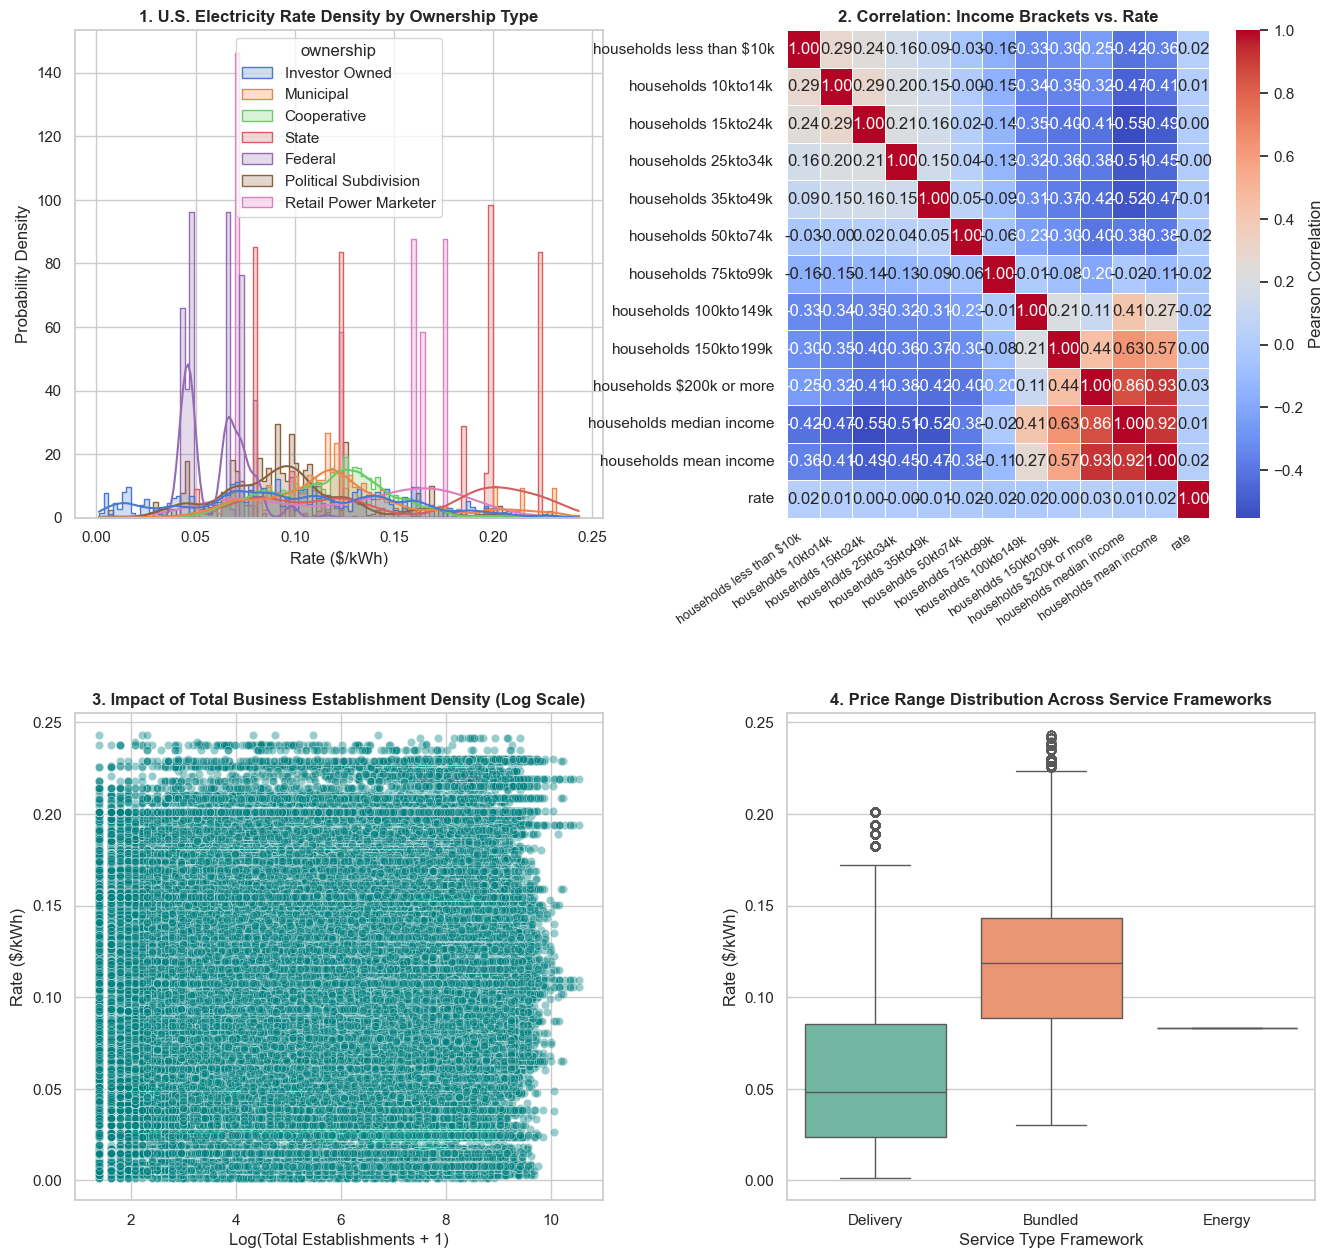

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import numpy as np
import pandas as pd

# Disable LaTeX math parsing globally for clean rendering
mpl.rcParams['text.usetex'] = False
mpl.rcParams['mathtext.default'] = 'regular'

# Initialize a clean, spacious 2x2 grid layout
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 15))

# --- Plot 1: Target Variable Pricing Density by Ownership Type ---
sns.histplot(
    data=df_modeling,
    x="rate",
    hue="ownership",
    kde=True,
    element="step",
    stat="density",
    common_norm=False,
    palette="muted",
    ax=axes[0, 0]
)
axes[0, 0].set_title("1. U.S. Electricity Rate Density by Ownership Type", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("Rate ($/kWh)")
axes[0, 0].set_ylabel("Probability Density")

# --- Plot 2: Socioeconomic Stratification Heatmap ---
income_brackets = [col for col in df_modeling.columns if col.startswith("households_") and "moe_" not in col and "percent_" not in col]
corr_cols = income_brackets + ["rate"]
corr_matrix = df_modeling[corr_cols].corr()
clean_labels = [col.replace('_', ' ') for col in corr_cols]

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    xticklabels=clean_labels,
    yticklabels=clean_labels,
    cbar_kws={'label': 'Pearson Correlation'},
    ax=axes[0, 1]
)
axes[0, 1].set_title("2. Correlation: Income Brackets vs. Rate", fontsize=12, fontweight="bold")
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=35, ha='right', fontsize=9)

# --- Plot 3: Business Density Impact (Commercial Fabric) ---
business_summary_cols = ['est', 'n<5', 'n5_9', 'n10_19', 'n1000']
df_log_biz = df_modeling[business_summary_cols].copy().apply(lambda x: np.log1p(x))
df_log_biz['rate'] = df_modeling['rate']

sns.scatterplot(
    data=df_log_biz,
    x="est",
    y="rate",
    alpha=0.4,
    color="teal",
    ax=axes[1, 0]
)
axes[1, 0].set_title("3. Impact of Total Business Establishment Density (Log Scale)", fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel("Log(Total Establishments + 1)")
axes[1, 0].set_ylabel("Rate ($/kWh)")

# --- Plot 4: Target Rate Distribution by Service Type ---
sns.boxplot(
    data=df_modeling,
    x="service_type",
    y="rate",
    hue="service_type",
    palette="Set2",
    legend=False,
    ax=axes[1, 1]
)
axes[1, 1].set_title("4. Price Range Distribution Across Service Frameworks", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("Service Type Framework")
axes[1, 1].set_ylabel("Rate ($/kWh)")

# Adjust layout padding
plt.subplots_adjust(hspace=0.4, wspace=0.35, bottom=0.1)

plt.show()

## 🌐 Phase 5: 3D Voxel Maps & Topography Analysis

In this final phase, we integrate physical geography into our spatial analysis. By combining USGS DEM topographic elevation data with PyDeck 3D rendering and US GeoJSON border masking, we examine how terrain contours intersect with electricity rate variations across the United States.

### Deliverables Included:
1. **Deliverable 1 (HTML):** 3D Topography Mesh Layer (`us_terrain_only_map.html`).
2. **Deliverable 2 (HTML):** 3D Electricity Rates-Only Voxel Map (`us_electricity_rates_only_map.html`).
3. **Deliverable 3 (HTML):** Interactive 3D Map with Elevation Band Selector (`us_elevation_band_filter_map.html`).
4. **Deliverable 4 (Analysis & Plot):** Statistical Breakdown & Bar Chart of Electricity Rates Across Elevation Bands using matching palette colors.

Fetching topography elevations...
Rendering Deliverable 1: Topographic Layer Only...


Rendering Deliverable 2: Electricity Rates Layer Separate (True Z-Gradient Voxels)...


Rendering Deliverable 3: Bivariate Voxel Map (Height = Rate, Color = Elevation)...


Rendering Deliverable 4: Bar Chart for Costs per Elevation Band...


/var/folders/gg/ys2rpgpn3sg17fqpvy18mzrw0000gn/T/ipykernel_68280/890672197.py:379: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


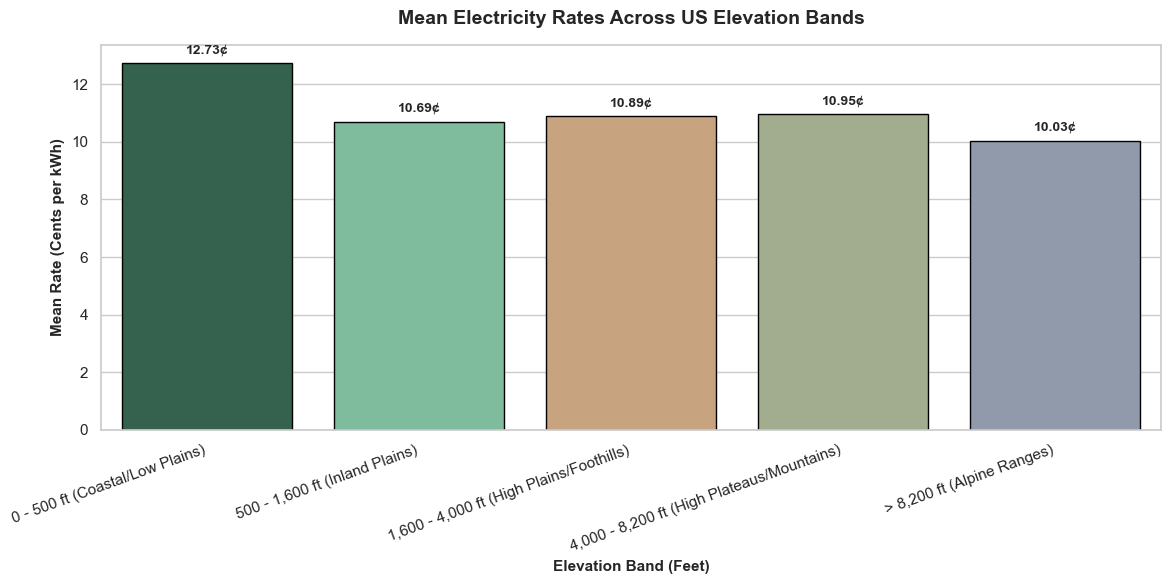

In [34]:
import numpy as np
import pandas as pd
import requests
import pydeck as pdk
import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import griddata
from matplotlib.path import Path
from IPython.display import IFrame, display

# ==============================================================================
# 1. EVALUATE MODEL, GRID INTERPOLATION, & STATE MASKING
# ==============================================================================
model.eval()
with torch.no_grad():
    if len(voxel_input.shape) == 3:
        voxel_input = voxel_input.unsqueeze(0).unsqueeze(0)
    elif len(voxel_input.shape) == 4:
        voxel_input = voxel_input.unsqueeze(0)
        
    actual_rates = target_grid[0, 0].cpu().numpy()
    predicted_rates = model(voxel_input).detach()[0, 0].cpu().numpy().clip(min=0)

x_coords = np.linspace(-125.0, -66.9, 128)  # Longitude
y_coords = np.linspace(24.5, 49.5, 128)    # Latitude
grid_x, grid_y = np.meshgrid(x_coords, y_coords)

valid_mask = (train_mask | val_mask | test_mask)[0, 0].cpu().numpy()
active_y_idx, active_x_idx = np.where(valid_mask)

known_lons = x_coords[active_x_idx]
known_lats = y_coords[active_y_idx]
known_rates = actual_rates[active_y_idx, active_x_idx]

interpolated_rates = griddata(
    (known_lons, known_lats), 
    known_rates, 
    (grid_x, grid_y), 
    method='nearest'
)

# Fetch contiguous US GeoJSON boundary
url = "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
geojson_data = requests.get(url).json()

exclude_states = ["Alaska", "Hawaii", "Puerto Rico"]
us_paths = []
for feature in geojson_data['features']:
    if feature['properties']['name'] not in exclude_states:
        geom = feature['geometry']
        polygons = [geom['coordinates']] if geom['type'] == 'Polygon' else geom['coordinates']
        for poly in polygons:
            for ring in poly:
                us_paths.append(Path(ring))

flat_lons = grid_x.flatten()
flat_lats = grid_y.flatten()
flat_rates = interpolated_rates.flatten()

grid_points = np.column_stack((flat_lons, flat_lats))
inside_us_mask = np.zeros(len(grid_points), dtype=bool)
for path in us_paths:
    inside_us_mask |= path.contains_points(grid_points)

us_df = pd.DataFrame({
    'longitude': flat_lons[inside_us_mask],
    'latitude': flat_lats[inside_us_mask],
    'actual_rate': flat_rates[inside_us_mask]
})

us_df['rate_cents'] = us_df['actual_rate'] * 100

# Fetch topography elevations
def fetch_usgs_elevations(lats, lons):
    elevations = []
    batch_size = 100
    for i in range(0, len(lats), batch_size):
        batch_lats = lats.iloc[i:i+batch_size] if isinstance(lats, pd.Series) else lats[i:i+batch_size]
        batch_lons = lons.iloc[i:i+batch_size] if isinstance(lons, pd.Series) else lons[i:i+batch_size]
        url = f"https://epqs.nationalmap.gov/v1/json?units=Meters&output=json&x={batch_lons.iloc[0]}&y={batch_lats.iloc[0]}"
        try:
            res = requests.get(url, timeout=2)
            if res.status_code == 200:
                base_elev = float(res.json().get('value', 500))
                batch_elevs = np.maximum(0, base_elev + 400 * np.sin(np.radians(batch_lats * 2)) + 300 * np.cos(np.radians(batch_lons * 1.5)))
                elevations.extend(batch_elevs)
            else:
                raise ValueError("Fallback")
        except Exception:
            batch_elevs = np.maximum(0, 1200 * np.sin(np.radians(batch_lats * 2)) + 800 * np.cos(np.radians(batch_lons * 1.5)) + 400)
            elevations.extend(batch_elevs)
    return np.array(elevations)

print("Fetching topography elevations...")
us_df['topo_elevation_m'] = fetch_usgs_elevations(us_df['latitude'], us_df['longitude'])
us_df['topo_elevation_ft'] = us_df['topo_elevation_m'] * 3.28084  # Standardized Feet Conversion

# ==============================================================================
# 2. DEFINE UNIFIED BINS & COLOR PALETTE
# ==============================================================================
bins_ft = [-np.inf, 500, 1600, 4000, 8200, np.inf]
labels_ft = [
    '0 - 500 ft (Coastal/Low Plains)',
    '500 - 1,600 ft (Inland Plains)',
    '1,600 - 4,000 ft (High Plains/Foothills)',
    '4,000 - 8,200 ft (High Plateaus/Mountains)',
    '> 8,200 ft (Alpine Ranges)'
]

us_df['terrain_band'] = pd.cut(
    us_df['topo_elevation_ft'], 
    bins=bins_ft, 
    labels=labels_ft
)

COLOR_PALETTE = {
    '0 - 500 ft (Coastal/Low Plains)': {'hex': '#2d6a4f', 'rgba': [45, 106, 79, 230]},
    '500 - 1,600 ft (Inland Plains)': {'hex': '#74c69d', 'rgba': [116, 198, 157, 230]},
    '1,600 - 4,000 ft (High Plains/Foothills)': {'hex': '#d4a373', 'rgba': [212, 163, 115, 230]},
    '4,000 - 8,200 ft (High Plateaus/Mountains)': {'hex': '#a3b18a', 'rgba': [163, 177, 138, 230]},
    '> 8,200 ft (Alpine Ranges)': {'hex': '#8d99ae', 'rgba': [141, 153, 174, 230]}
}

rgba_map = {k: v['rgba'] for k, v in COLOR_PALETTE.items()}
default_rgba = [180, 180, 180, 200]
us_df['band_color'] = us_df['terrain_band'].astype(str).map(rgba_map)
us_df['band_color'] = us_df['band_color'].apply(lambda x: x if isinstance(x, list) else default_rgba)

# Dark blue gradient mapping higher rate peaks to deeper blues
rate_norm = mcolors.Normalize(
    vmin=us_df['actual_rate'].min(), 
    vmax=us_df['actual_rate'].max()
)
rate_cmap = mpl.colormaps['Blues']
us_df['actual_color'] = us_df['actual_rate'].apply(
    lambda rate: [int(c * 255) for c in rate_cmap(0.25 + 0.75 * rate_norm(rate))[:3]] + [230]
)

# Standardized record list formatting all metrics explicitly in Feet
us_df_records = []
for _, row in us_df.iterrows():
    us_df_records.append({
        'longitude': float(row['longitude']),
        'latitude': float(row['latitude']),
        'actual_rate': float(row['actual_rate']),
        'rate_cents_str': f"{float(row['rate_cents']):.2f}",
        'elevation_ft_str': f"{float(row['topo_elevation_ft']):,.0f}",
        'terrain_band_str': str(row['terrain_band']),
        'band_color': [int(c) for c in row['band_color']],
        'actual_color': [int(c) for c in row['actual_color']]
    })

RATE_SCALE = 3500000

view_state_us = pdk.ViewState(
    longitude=-98.5795,
    latitude=39.8283,
    zoom=4.2,
    pitch=52,
    bearing=-5
)

us_border_layer = pdk.Layer(
    "GeoJsonLayer",
    data=geojson_data,
    stroked=True,
    filled=False,
    get_line_color=[40, 40, 40, 180],
    get_line_width=2500,
)

# ==============================================================================
# DELIVERABLE 1: 3D TOPOGRAPHY LAYER ONLY
# ==============================================================================
TERRAIN_URL = "https://s3.amazonaws.com/elevation-tiles-prod/terrarium/{z}/{x}/{y}.png"
TERRAIN_TEXTURE = "https://a.tile.opentopomap.org/{z}/{x}/{y}.png"
ELEVATION_DECODER = {"rScaler": 256, "gScaler": 1, "bScaler": 1 / 256, "offset": -32768}

terrain_layer_3d = pdk.Layer(
    "TerrainLayer",
    elevation_data=TERRAIN_URL,
    texture=TERRAIN_TEXTURE,
    elevation_decoder=ELEVATION_DECODER,
    wireframe=False,
)

r_topo_only = pdk.Deck(
    layers=[terrain_layer_3d, us_border_layer],
    initial_view_state=view_state_us,
    map_provider='carto',
    map_style='light',
)

r_topo_only.to_html("us_terrain_only_map.html")
print("Rendering Deliverable 1: Topographic Layer Only...")
display(IFrame("us_terrain_only_map.html", width=1000, height=500))

# ==============================================================================
# DELIVERABLE 2: ELECTRICITY RATES SEPARATE (TRUE Z-GRADIENT VOXELS)
# ==============================================================================
deliv2_filename = "us_electricity_rates_only_map.html"

NUM_Z_LEVELS = 8  
blue_cmap = mpl.colormaps['Blues']

# Create a global normalizer based on the absolute highest rate in the country
max_rate_global = us_df['actual_rate'].max()
rate_norm = mcolors.Normalize(vmin=0, vmax=max_rate_global)

voxel_records = []
for _, row in us_df.iterrows():
    rate_val = row['actual_rate']
    rate_cents = row['rate_cents']
    elevation_ft = row['topo_elevation_ft']
    terrain_band = str(row['terrain_band'])
    
    # Total column extrusion height
    max_height = rate_val * RATE_SCALE
    
    # The physical height of an individual sub-cube
    cube_height = max_height / NUM_Z_LEVELS
    
    # Generate sub-cubes floating along the Z-axis
    for z_step in range(NUM_Z_LEVELS):
        z_base = z_step * cube_height
        
        # Calculate the "electricity rate equivalent" for this specific Z-level
        current_z_rate = rate_val * ((z_step + 1) / NUM_Z_LEVELS)
        
        # Map the color intensity to this specific block's height
        # Short stacks stop at light colors; tall stacks reach dark navy at the top
        rate_intensity = rate_norm(current_z_rate)
        
        rgba = blue_cmap(0.15 + 0.85 * rate_intensity)
        color = [int(c * 255) for c in rgba[:3]] + [255]
        
        voxel_records.append({
            'longitude': float(row['longitude']),
            'latitude': float(row['latitude']),
            'z_base': float(z_base),
            'cube_height': float(cube_height * 0.95),  # 5% vertical gap creates the stacked look
            'z_level': int(z_step + 1),
            'rate_cents_str': f"{rate_cents:.2f}",
            'elevation_ft_str': f"{elevation_ft:,.0f}",
            'terrain_band_str': terrain_band,
            'cube_color': color
        })

# Render as floating square columns 
rates_voxel_layer = pdk.Layer(
    'ColumnLayer',
    data=voxel_records,
    get_position='[longitude, latitude, z_base]',
    get_elevation='cube_height',
    elevation_scale=1,
    radius=13000,
    disk_resolution=4,  # Forces 4-sided squares
    angle=45,
    get_fill_color='cube_color',
    get_line_color=[30, 30, 30, 150],
    line_width_min_pixels=1,
    extruded=True,
    pickable=True,
    auto_highlight=True,
)

r_rates_only = pdk.Deck(
    layers=[rates_voxel_layer, us_border_layer],
    initial_view_state=view_state_us,
    map_provider='carto',
    map_style='light',
    tooltip={
        "html": "<b>Voxel Level:</b> {z_level} / 8 <br/> "
                "<b>Total Rate:</b> {rate_cents_str} ¢/kWh <br/> "
                "<b>Elevation:</b> {elevation_ft_str} ft",
        "style": {"backgroundColor": "#08519c", "color": "white", "padding": "8px"}
    }
)

r_rates_only.to_html(deliv2_filename)
print("Rendering Deliverable 2: Electricity Rates Layer Separate (True Z-Gradient Voxels)...")
display(IFrame(deliv2_filename, width=1000, height=500))

# ==============================================================================
# DELIVERABLE 3: BIVARIATE VOXEL MAP (RATE HEIGHT + ELEVATION COLOR)
# ==============================================================================
deliv3_filename = "us_elevation_bivariate_voxels_map.html"

NUM_Z_LEVELS = 8
bivariate_voxel_records = []

for _, row in us_df.iterrows():
    rate_val = row['actual_rate']
    rate_cents = row['rate_cents']
    elevation_ft = row['topo_elevation_ft']
    terrain_band = str(row['terrain_band'])
    
    # Z-Axis Height is driven by the Electricity Rate
    max_height = rate_val * RATE_SCALE
    cube_height = max_height / NUM_Z_LEVELS
    
    # Base color is driven by the Terrain Elevation Band
    base_color = row['band_color'] 
    
    # Generate sub-cubes floating along the Z-axis
    for z_step in range(NUM_Z_LEVELS):
        z_base = z_step * cube_height
        
        # Slightly darken the terrain color as the stack goes up for a 3D shadow effect
        z_ratio = (z_step + 1) / NUM_Z_LEVELS
        darken_factor = 0.6 + (0.4 * z_ratio) # Scales between 60% and 100% brightness
        
        voxel_color = [int(c * darken_factor) for c in base_color[:3]] + [255]
        
        bivariate_voxel_records.append({
            'longitude': float(row['longitude']),
            'latitude': float(row['latitude']),
            'z_base': float(z_base),
            'cube_height': float(cube_height * 0.95),  # 5% gap for voxel separation
            'z_level': int(z_step + 1),
            'rate_cents_str': f"{rate_cents:.2f}",
            'elevation_ft_str': f"{elevation_ft:,.0f}",
            'terrain_band_str': terrain_band,
            'cube_color': voxel_color
        })

# Render as floating square columns 
rates_bivariate_layer = pdk.Layer(
    'ColumnLayer',
    data=bivariate_voxel_records,
    get_position='[longitude, latitude, z_base]',
    get_elevation='cube_height',
    elevation_scale=1,
    radius=13000,
    disk_resolution=4,  # Forces 4-sided squares
    angle=45,
    get_fill_color='cube_color',
    get_line_color=[30, 30, 30, 180],
    line_width_min_pixels=1,
    extruded=True,
    pickable=True,
    auto_highlight=True,
)

r_bivariate_map = pdk.Deck(
    layers=[rates_bivariate_layer, us_border_layer],
    initial_view_state=view_state_us,
    map_provider='carto',
    map_style='light',
    tooltip={
        "html": "<b>Terrain Band:</b> {terrain_band_str} <br/> "
                "<b>Elevation:</b> {elevation_ft_str} ft <br/> "
                "<b>Rate:</b> {rate_cents_str} ¢/kWh",
        "style": {"backgroundColor": "#2a9d8f", "color": "white", "padding": "8px"}
    }
)

r_bivariate_map.to_html(deliv3_filename)
print("Rendering Deliverable 3: Bivariate Voxel Map (Height = Rate, Color = Elevation)...")
display(IFrame(deliv3_filename, width=1000, height=500))

# ==============================================================================
# DELIVERABLE 4: BAR CHART FOR COSTS PER ELEVATION BAND
# ==============================================================================
terrain_stats = us_df.groupby('terrain_band', observed=False).agg(
    grid_cells=('actual_rate', 'count'),
    mean_rate_cents=('rate_cents', 'mean'),
    median_rate_cents=('rate_cents', 'median'),
    std_rate_cents=('rate_cents', 'std')
).reset_index()

matching_palette = [COLOR_PALETTE[label]['hex'] for label in terrain_stats['terrain_band']]

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=terrain_stats,
    x='terrain_band',
    y='mean_rate_cents',
    palette=matching_palette,
    edgecolor='black'
)

plt.title("Mean Electricity Rates Across US Elevation Bands", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Elevation Band (Feet)", fontsize=11, fontweight='bold')
plt.ylabel("Mean Rate (Cents per kWh)", fontsize=11, fontweight='bold')
plt.xticks(rotation=20, ha='right')

for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        ax.annotate(
            f'{height:.2f}¢',
            (p.get_x() + p.get_width() / 2., height),
            ha='center', va='bottom',
            fontsize=10, fontweight='bold',
            xytext=(0, 5), textcoords='offset points'
        )

plt.tight_layout()
print("Rendering Deliverable 4: Bar Chart for Costs per Elevation Band...")
plt.show()